In [17]:
# -*- coding: utf-8 -*-
"""
@author: Jesper
"""
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
from matplotlib.animation import FuncAnimation
import time
from scipy.optimize import curve_fit
from pathlib import Path


from matplotlib.ticker import FuncFormatter

def engineering_formatter(x, pos):
    if x >= 1e6:
        return f"{x/1e6:g}M"
    elif x >= 1e3:
        return f"{x/1e3:g}k"
    else:
        return f"{x:g}"

# ------------------ Plot settings ------------------
plt.rcParams['figure.figsize'] = (10, 6)        # Default figure size
plt.rcParams['figure.dpi'] = 100                # Resolution
plt.rcParams['font.size'] = 16                  # Font size
plt.rcParams['axes.titlesize'] = 14             # Title font size
plt.rcParams['axes.labelsize'] = 22             # Axis label font size
plt.rcParams['xtick.labelsize'] = 19            # X-tick label size
plt.rcParams['ytick.labelsize'] = 19            # Y-tick label size
plt.rcParams['legend.fontsize'] = 22            # Legend font size
plt.rcParams['lines.linewidth'] = 2             # Line width
plt.rcParams['axes.grid'] = True                # Show grid by default
plt.rcParams['grid.alpha'] = 0.3                # Grid transparency

# Set global tick mark (line) sizes
plt.rcParams['xtick.major.size'] = 8      # Major tick length (horizontal)
plt.rcParams['ytick.major.size'] = 8      # Major tick length (vertical)
plt.rcParams['xtick.minor.size'] = 4      # Minor tick length (horizontal)
plt.rcParams['ytick.minor.size'] = 4      # Minor tick length (vertical)

# Set tick width
plt.rcParams['xtick.major.width'] = 1.5   # Major tick width (horizontal)
plt.rcParams['ytick.major.width'] = 1.5   # Major tick width (vertical)
plt.rcParams['xtick.minor.width'] = 1.5   # Major tick width (horizontal)
plt.rcParams['ytick.minor.width'] = 1.5   # Major tick width (vertical)
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Palatino", "Book Antiqua", "DejaVu Serif"],
})

In [2]:
def correct_iq(I, Q, return_params=False):

    I = np.asarray(I, dtype=float)
    Q = np.asarray(Q, dtype=float)
 
    dc_I = np.mean(I)
    dc_Q = np.mean(Q)
    I1 = I - dc_I
    Q1 = Q - dc_Q
 
    gain_I = np.sqrt(np.mean(I1 ** 2))
    gain_Q = np.sqrt(np.mean(Q1 ** 2))
 
    I2 = I1 / gain_I
    Q2 = Q1 / gain_Q
    
    cross = np.mean(I2 * Q2)
    sin_delta = np.clip(cross, -1.0, 1.0)
    delta = np.arcsin(sin_delta)
 
    cos_delta = np.cos(delta)

    I_corr = I2
    Q_corr = (Q2 - I2 * np.sin(delta)) / cos_delta
 
    if return_params:
        params = {
            'dc_I':      dc_I,
            'dc_Q':      dc_Q,
            'gain_I':    gain_I,
            'gain_Q':    gain_Q,
            'delta':     delta,
            'delta_deg': np.degrees(delta),
        }
        return I_corr, Q_corr, params
 
    return I_corr, Q_corr

In [3]:
def read_metadata(filename):
    meta = {}

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if ":" not in line:
                continue

            parts = line.split(":")
            
            # Most entries are Key:Value:
            if len(parts) >= 2:
                key = parts[0]
                value = parts[1]

                meta[key] = value

    # --------------------------------------------------
    # Extract powers from filename
    # Example:
    # PPCL550_Dither_14.66dBm_7.51+12.14dBm_no1.csv
    # --------------------------------------------------

    basename = filename.split("/")[-1]
    basename = basename.split("\\")[-1]

    match = re.search(
        r'([-+]?\d+(?:\.\d+)?)dBm_([-+]?\d+(?:\.\d+)?)\+([-+]?\d+(?:\.\d+)?)dBm',
        basename
    )


    if match:
        meta["TotalOutputPower_dBm"] = float(match.group(1))
        meta["SignalPower_dBm"] = float(match.group(2))
        meta["LOPower_dBm"] = float(match.group(3))

    meta["MeasurementName"] = basename


    return meta

In [23]:
from matplotlib import lines


def read_and_process_csv(filename = None, foldername = None, path = None, offset_handling = False):
    """ Reads and processes a CSV file containing time and channel data. It handles metadata, scaling, and offset adjustments based on the provided parameters.
        Input is a filename without suffix, a foldername, and an optional path. If the path is provided, it will be used instead of constructing the file path from the foldername and filename. The function reads the metadata from a corresponding .csv file and applies scaling and offset adjustments to the channel data if necessary. It returns the time array, channel data arrays, and the size of the data.
    """

    if path == None:
        file_path = fr'{foldername}/{filename}.csv'
    else:
        file_path = path
    print(file_path)

    meta = read_metadata(file_path[:-8] + ".csv") #since data file is filename + .wfm.csv and metadata file is + .csv

    dt = float(meta["SignalResolution"])
    signal_format = meta.get("SignalFormat", "").upper()
    is_raw_adc =  signal_format.startswith("INT") 

    if is_raw_adc:
        no_of_quant = int(meta["NofQuantisationLevels"])
        y_volt_start = float(meta["BaseYStart"])
        y_volt_stop = float(meta["BaseYStop"])

        scale = (y_volt_stop - y_volt_start) / (no_of_quant)

        if offset_handling:        
            vertical_offset = float(meta["VerticalOffset"]) 
        else:
            vertical_offset = 0.0

        
    print("now proccessing file at path: ", file_path)
    df = pd.read_csv(file_path, header=None, delimiter=';')
    if len(df.columns) == 5:
        df.columns = ['time', 'ch_1', 'ch_2', 'ch_3', 'ch_4']
        time = df['time']

        if is_raw_adc:
            ch_one = df['ch_1'] * scale + vertical_offset
            ch_two = df['ch_2'] * scale + vertical_offset
            ch_three = df['ch_3'] * scale + vertical_offset
            ch_four = df['ch_4'] * scale + vertical_offset
        else:
            ch_one = df['ch_1']    
            ch_two = df['ch_2']    
            ch_three = df['ch_3']    
            ch_four = df['ch_4']

        size = len(ch_one)
        print("Size: ", size)
        print("Frequency resolution: ", 1/(time[1] - time[0]))
        
        return time[0:size], ch_one[0:size], ch_two[0:size], ch_three[0:size], ch_four[0:size], size

    elif len(df.columns) == 4:
            df.columns = ['ch_1', 'ch_2', 'ch_3', 'ch_4']

            if is_raw_adc:
                ch_one = df['ch_1'] * scale + vertical_offset
                ch_two = df['ch_2'] * scale + vertical_offset
                ch_three = df['ch_3'] * scale + vertical_offset
                ch_four = df['ch_4'] * scale + vertical_offset
            else:
                ch_one = df['ch_1']    
                ch_two = df['ch_2']    
                ch_three = df['ch_3']    
                ch_four = df['ch_4']
            size = len(ch_one)

            time = np.arange(size) * dt

            # df['time'] = time #Adding time column to the dataframe
      

            print("Size: ", size)
            print("Frequency resolution: ", 1/(time[1] - time[0]))
            
            return time[0:size], ch_one[0:size], ch_two[0:size], ch_three[0:size], ch_four[0:size], size
    
        
    
def pnpsd(filenames, foldername, averaging_number):
    """
    Calculates sdd for phase noise power spectral density using cross spectral density csd. Returns the PN-PSD. 
    """   
    timeX, ch_one, ch_two, ch_three, ch_four, size = read_and_process_csv(filenames, foldername)

    NN=size//averaging_number               # // to make sure that it gets an integer and not a float
    window = scipy.signal.get_window('hann', NN)

    psdxx0=0
    fxx=0

    psdyy0=0
    fyy=0

    psdxy0=0
    fxy=0

    ch_one, ch_two = correct_iq(ch_one, ch_two)
    ch_three, ch_four = correct_iq(ch_three, ch_four)

    phaseX,sampling_rateX=pp(ch_one, ch_two, timeX)
    phaseY,sampling_rateY=pp(ch_three, ch_four, timeX)

    ffxx = 0
    Pxx_den = 0

    ffxy = 0
    Pxy_den = 0

    ffyy = 0
    Pyy_den = 0

    ffxx, Pxx_den = scipy.signal.csd(phaseX, phaseX, fs=sampling_rateX,window=window,nperseg=NN)
    psdxx0=psdxx0 + Pxx_den
    fxx=ffxx+fxx

    ffxy, Pxy_den = scipy.signal.csd(phaseX, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdxy0=psdxy0 + Pxy_den
    fxy=ffxy+fxy

    ffyy, Pyy_den = scipy.signal.csd(phaseY, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdyy0=psdyy0 + Pyy_den
    fyy=ffyy+fyy

    psdxx0=np.abs(psdxx0)

    psdyy0=np.abs(psdyy0)

    psdxy0=np.abs(psdxy0)

    # Shitty namings, but it returns frequency and PN-PSD for the x-polarization, y-polarization and the cross correlated

    return fxx, psdxx0, fyy, psdyy0, fxy, psdxy0



    
def pnpsd_alt(phaseX, phaseY, sampling_rate, size, averaging_number):
    """
    Calculates sdd for phase noise power spectral density using cross spectral density csd. Returns the PN-PSD. 
    """   

    NN=size//averaging_number               # // to make sure that it gets an integer and not a float
    window = scipy.signal.get_window('hann', NN)

    psdxx0=0
    fxx=0

    psdyy0=0
    fyy=0

    psdxy0=0
    fxy=0


    ffxx = 0
    Pxx_den = 0

    ffxy = 0
    Pxy_den = 0

    ffyy = 0
    Pyy_den = 0

    ffxx, Pxx_den = scipy.signal.csd(phaseX, phaseX, fs=sampling_rate,window=window,nperseg=NN)
    psdxx0=psdxx0 + Pxx_den
    fxx=ffxx+fxx

    ffxy, Pxy_den = scipy.signal.csd(phaseX, phaseY, fs=sampling_rate,window=window,nperseg=NN)
    psdxy0=psdxy0 + Pxy_den
    fxy=ffxy+fxy

    ffyy, Pyy_den = scipy.signal.csd(phaseY, phaseY, fs=sampling_rate,window=window,nperseg=NN)
    psdyy0=psdyy0 + Pyy_den
    fyy=ffyy+fyy

    psdxx0=np.abs(psdxx0)

    psdyy0=np.abs(psdyy0)

    psdxy0=np.abs(psdxy0)

    # Shitty namings, but it returns frequency and PN-PSD for the x-polarization, y-polarization and the cross correlated

    return fxx, psdxx0, fyy, psdyy0, fxy, psdxy0



def pnpsd_noQAM(filenames, foldername, averaging_number):
    """
    Calculates sdd for phase noise power spectral density using cross spectral density csd. Returns the PN-PSD. 
    """   
    timeX, ch_one, ch_two, ch_three, ch_four, size = read_and_process_csv(filenames, foldername)

    NN=size//averaging_number               # // to make sure that it gets an integer and not a float
    window = scipy.signal.get_window('hann', NN)

    psdxx0=0
    fxx=0

    psdyy0=0
    fyy=0

    psdxy0=0
    fxy=0

    phaseX,sampling_rateX=pp(ch_one, ch_two, timeX)
    phaseY,sampling_rateY=pp(ch_three, ch_four, timeX)

    ffxx = 0
    Pxx_den = 0

    ffxy = 0
    Pxy_den = 0

    ffyy = 0
    Pyy_den = 0

    ffxx, Pxx_den = scipy.signal.csd(phaseX, phaseX, fs=sampling_rateX,window=window,nperseg=NN)
    psdxx0=psdxx0 + Pxx_den
    fxx=ffxx+fxx

    ffxy, Pxy_den = scipy.signal.csd(phaseX, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdxy0=psdxy0 + Pxy_den
    fxy=ffxy+fxy

    ffyy, Pyy_den = scipy.signal.csd(phaseY, phaseY, fs=sampling_rateX,window=window,nperseg=NN)
    psdyy0=psdyy0 + Pyy_den
    fyy=ffyy+fyy

    psdxx0=np.abs(psdxx0)

    psdyy0=np.abs(psdyy0)

    psdxy0=np.abs(psdxy0)

    return fxx, psdxx0, fyy, psdyy0, fxy, psdxy0

def pp(XI,XQ,time):
    """
    Returns the accumulated phase using the arctan2 function and the sampling rate by
    """
    phase= np.unwrap(np.arctan2(XQ, XI))
    dt=time[2]-time[1]
    sampling_rate=1/dt
    return phase, sampling_rate

def fnpsd(fxy, psdxy, FSR):
    # fsdd for frequency noise power spectral density. Returns the FN-PSD.

    fsdxy = []

    for i, _ in enumerate(fxy):
        fsdxy.append(fxy[i] ** 2 / (4 * np.sin(np.pi * fxy[i] * 1/FSR) ** 2) * psdxy[i])
            
    return np.array(fxy),np.array(fsdxy)


def find_fsr(freq, pn_psd, FSR_est, upper_lim, peak_skips=0, show_detection = False):

    # Function for finding the FSR from the dips, that is needed for the PN --> FN conversion. Returns the average distance 
    # between the dips as the FSR and the peaks that are detected.

    # Since 

    def model_plus(f, A, B, C):
        return A / (f**2) + B / (f**3) + C

    def fit_one_over_f_squared_plus(f, y):
        popt, pcov = curve_fit(model_plus, f, y, p0=(6e2, 1e9, 1))
        return popt, pcov

    f_min = (0.75)/(FSR_est / (3e8/1.46))
    mask = (freq < upper_lim) & (freq > f_min)
    f_sub = freq[mask]
    psd_sub = -pn_psd[mask]

    delta_f = f_min
    df = freq[1] - freq[0]

    delta_i = int(round(delta_f / df))

    peaks, props = scipy.signal.find_peaks(psd_sub, distance = delta_i*0.9)

    peak_temp = f_sub[peaks][peak_skips:]
    psd_temp = -psd_sub[peaks][peak_skips:]

    f_dist_peaks = np.median(np.diff(peak_temp))

    popt, pcov = fit_one_over_f_squared_plus(f_sub[peaks][peak_skips:], -psd_sub[peaks][peak_skips:])

    if show_detection:
        fig, ax = plt.subplots(figsize =(20, 7.5))
        ax.loglog(freq, pn_psd, label = "Input signal")
        #ax.loglog(freq, model(freq, popt[0], popt[1]), label = "1/f^2 fit")

        ax.scatter(peak_temp, psd_temp, label = "Detected fringes", color = "red")

        ax.loglog(freq, model_plus(freq, popt[0], popt[1], popt[2]), linestyle = "dashed", color = "black")

        ax.vlines(f_min, min(pn_psd), max(pn_psd), label = "Limits for detection", linestyles="dashed", color = "black")

        ax.vlines(upper_lim, min(pn_psd), max(pn_psd), linestyles="dashed", color = "black")

        print("Params from fit:")
        print("A = ", popt[0])
        print("B = ", popt[1])
        print("C = ", popt[2])

        ax.set_title("Detected dips in the PN-FSD for FSR determination", fontsize = 25)
        ax.set_ylabel(rf"PN-FSD [rad$^2$/Hz]")
        ax.set_xlabel("Fourier frequencies [Hz]")
        ax.set_xlim(1e2, 1e7)
        ax.legend(loc="upper right")
        
    return f_dist_peaks, f_sub[peaks], -psd_sub[peaks]


In [5]:
def analyze_data(
        filename,
        foldername,
        averaging_number,
        delay = 700,
        offset_handling=False):


    file_path = fr"{foldername}/{filename}.csv"

    meta = read_metadata(file_path[:-8] + ".csv")
    dt = float(meta["SignalResolution"])

    # --------------------------------------------------
    # Read waveform
    # --------------------------------------------------
   

    time, Ix, Qx, Iy, Qy, size = read_and_process_csv(
        filename=filename,
        foldername=foldername,
        offset_handling=offset_handling
    )

    # Keep original traces
    Ix_raw = Ix.copy()
    Qx_raw = Qx.copy()
    Iy_raw = Iy.copy()
    Qy_raw = Qy.copy()

    # --------------------------------------------------
    # IQ correction
    # --------------------------------------------------

    Ix_corr, Qx_corr = correct_iq(Ix, Qx)
    Iy_corr, Qy_corr = correct_iq(Iy, Qy)

    # --------------------------------------------------
    # Incremental phase, sampling rate
    # --------------------------------------------------

    phase_inc_x, fs = pp(Ix_corr, Qx_corr, time)
    phase_inc_y, _  = pp(Iy_corr, Qy_corr, time)

    # --------------------------------------------------
    # Autocorrelation
    # --------------------------------------------------

    autocorr_x = scipy.signal.correlate(
        phase_inc_x,
        phase_inc_x,
        mode="same"
    )

    autocorr_y = scipy.signal.correlate(
        phase_inc_y,
        phase_inc_y,
        mode="same"
    )

    lags = scipy.signal.correlation_lags(
        len(phase_inc_x),
        len(phase_inc_x),
        mode="same"
    )
    lags_time = lags.copy() * dt

        # --------------------------------------------------
    # Autocorrelation centered
    # --------------------------------------------------

    phase_centered_x = phase_inc_x - np.mean(phase_inc_x)
    phase_centered_y = phase_inc_y - np.mean(phase_inc_y)

    autocorr_x_centered = scipy.signal.correlate(
        phase_centered_x,
        phase_centered_x,
        mode="same"
    )

    autocorr_y_centered = scipy.signal.correlate(
        phase_centered_y,
        phase_centered_y,
        mode="same"
    )


    # --------------------------------------------------
    # PN PSD
    # --------------------------------------------------

    fxx, pn_x, fyy, pn_y, fxy, pn_xy = pnpsd_alt(phase_inc_x, phase_inc_y, fs, size, averaging_number)

    # --------------------------------------------------
    # FSR
    #---------------------------------------------------

    n = 1.5
    c = 3e8
    FSR_est = c / (n * delay)

    FSR, peaks_freq, peaks_psd = find_fsr(fxx, pn_x, FSR_est=FSR_est, upper_lim=1e7)

    # --------------------------------------------------
    # FN PSD
    # --------------------------------------------------

    _, fn_x = fnpsd(fxx, pn_x, FSR)
    _, fn_y = fnpsd(fyy, pn_y, FSR)
    _, fn_xy = fnpsd(fxy, pn_xy, FSR)


    # --------------------------------------------------
    # Time-domain dataframe
    # --------------------------------------------------

    df_time = pd.DataFrame({
        "time": time,

        "Ix_raw": Ix_raw,
        "Qx_raw": Qx_raw,
        "Iy_raw": Iy_raw,
        "Qy_raw": Qy_raw,

        "Ix_corr": Ix_corr,
        "Qx_corr": Qx_corr,
        "Iy_corr": Iy_corr,
        "Qy_corr": Qy_corr,

        "phase_inc_x": phase_inc_x,
        "phase_inc_y": phase_inc_y,
    })

    # --------------------------------------------------
    # Autocorrelation dataframe
    # --------------------------------------------------

    df_autocorr = pd.DataFrame({
        "lag_samples": lags,
        "lag_time": lags_time,
        "autocorr_x": autocorr_x,
        "autocorr_y": autocorr_y,
        "autocorr_x_centered": autocorr_x_centered,
        "autocorr_y_centered": autocorr_y_centered
    })

    # --------------------------------------------------
    # Frequency-domain dataframe
    # --------------------------------------------------

    df_freq = pd.DataFrame({
        "frequency": fxx,

        "pn_x": pn_x,
        "pn_y": pn_y,
        "pn_xy": pn_xy,

        "fn_x": fn_x,
        "fn_y": fn_y,
        "fn_xy": fn_xy
    })

    return {
        "time_domain": df_time,
        "autocorrelation": df_autocorr,
        "frequency_domain": df_freq,
        "meta data": meta,
        "FSR": FSR
    }

In [19]:
def plot_lissajous(
        label_name,
        time_domain_df,
        polarization="x",
        corrected=True,
        ax=None,
        plot_settings=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,8))

    if polarization.lower() == "x":

        I = (
            time_domain_df["Ix_corr"]
            if corrected
            else time_domain_df["Ix_raw"]
        )

        Q = (
            time_domain_df["Qx_corr"]
            if corrected
            else time_domain_df["Qx_raw"]
        )

        pol_label = "X"

    else:

        I = (
            time_domain_df["Iy_corr"]
            if corrected
            else time_domain_df["Iy_raw"]
        )

        Q = (
            time_domain_df["Qy_corr"]
            if corrected
            else time_domain_df["Qy_raw"]
        )

        pol_label = "Y"

    ax.plot(
        I,
        Q,
        ".",
        ms=1,
        label=f"{pol_label}-pol {label_name}"
    )

    if plot_settings:
        ax.set_xlabel("I [V]")
        ax.set_ylabel("Q [V]")
        ax.set_title(
            f"Lissajous Diagram ({pol_label}-pol)"
        )
        ax.axis("equal")
        ax.grid(True)
        ax.legend(loc="upper right")

    return ax


def plot_phase_increment(
        label_name,
        time_domain_df,
        plot_x=True,
        plot_y=True,
        ax=None,
        plot_settings=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    if plot_x:
        ax.plot(
            time_domain_df["time"],
            time_domain_df["phase_inc_x"],
            label=f"X-pol {label_name}"
        )

    if plot_y:
        ax.plot(
            time_domain_df["time"],
            time_domain_df["phase_inc_y"],
            label=f"Y-pol {label_name}"
        )

    if plot_settings:
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Phase increment [rad]")

        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

    return ax


def plot_autocorrelation(
        label_name,
        autocorrelation_df,
        plot_x=True,
        plot_y=True,
        centered=False,
        use_time_lag=True,
        ax=None,
        plot_settings=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    x_axis = (
        autocorrelation_df["lag_time"]
        if use_time_lag
        else autocorrelation_df["lag_samples"]
    )

    x_label = (
        "Lag time [s]"
        if use_time_lag
        else "Lag samples"
    )

    x_col = "autocorr_x_centered" if centered else "autocorr_x"
    y_col = "autocorr_y_centered" if centered else "autocorr_y"

    if plot_x:
        ax.plot(
            x_axis,
            autocorrelation_df[x_col],
            label=f"X-pol {label_name}"
        )

    if plot_y:
        ax.plot(
            x_axis,
            autocorrelation_df[y_col],
            label=f"Y-pol {label_name}"
        )

    if plot_settings:
        ax.set_xlabel(x_label)
        ax.set_ylabel(r"Autocorrelation centered [rad$^2$]" if centered else "Autocorrelation [rad$^2$]")
        ax.grid(True)
        ax.legend(loc="upper right")

    return ax




def plot_pnpsd(
        label_name,
        frequency_domain_df,
        plot_x=True,
        plot_y=True,
        plot_xy=True,
        ax=None,
        plot_settings=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    freq = frequency_domain_df["frequency"]

    if plot_x:
        ax.loglog(
            freq,
            frequency_domain_df["pn_x"],
            label=f"X-pol {label_name}"
        )

    if plot_y:
        ax.loglog(
            freq,
            frequency_domain_df["pn_y"],
            label=f"Y-pol {label_name}"
        )

    if plot_xy:
        ax.loglog(
            freq,
            frequency_domain_df["pn_xy"],
            label=f"XY-pol {label_name}"
        )

    if plot_settings:

        ax.xaxis.set_major_formatter(
            FuncFormatter(engineering_formatter)
        )

        ax.set_xlabel("Fourier frequency [Hz]")
        ax.set_ylabel(r"PN PSD [rad$^2$/Hz]")

        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="upper right")

    return ax




def plot_fnpsd(
        label_name,
        frequency_domain_df,
        plot_x=True,
        plot_y=True,
        plot_xy=True,
        ax=None,
        plot_settings=True):

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    freq = frequency_domain_df["frequency"]

    if plot_x:
        ax.loglog(
            freq,
            frequency_domain_df["fn_x"],
            label=f"X-pol {label_name}"
        )

    if plot_y:
        ax.loglog(
            freq,
            frequency_domain_df["fn_y"],
            label=f"Y-pol {label_name}"
        )

    if plot_xy:
        ax.loglog(
            freq,
            frequency_domain_df["fn_xy"],
            label=f"XY-pol {label_name}"
        )

    if plot_settings:

        ax.xaxis.set_major_formatter(
            FuncFormatter(engineering_formatter)
        )

        ax.set_xlabel("Fourier frequency [Hz]")
        ax.set_ylabel(r"FN PSD [Hz$^2$/Hz]")

        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="upper right")

    return ax

In [ ]:
def save_figure(fig, folder, basename, suffix):
    """
    Save figure as PDF and SVG.
    """

    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        folder / f"{basename}_{suffix}.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        folder / f"{basename}_{suffix}.svg",
        bbox_inches="tight"
    )

In [15]:
def plot_analysis_overview(
        label_name,
        result, save_folder=None):

    basename = Path(result["meta data"]["MeasurementName"]).stem


    # ----------------------------------
    # Lissajous X polarization
    # ----------------------------------

    fig, ax = plt.subplots(figsize=(8, 8))

    plot_lissajous(
        label_name,
        result["time_domain"],
        polarization="x",
        corrected=True,
        ax=ax,
        plot_settings=True
    )

    if save_folder is not None:
    
        save_figure(fig,save_folder,basename,"lissajous_x")

    # ----------------------------------
    # Lissajous Y polarization
    # ----------------------------------


    fig, ax = plt.subplots(figsize=(8, 8))

    plot_lissajous(
        label_name,
        result["time_domain"],
        polarization="y",
        corrected=True,
        ax=ax,
        plot_settings=True
    )

    if save_folder is not None:
    
        save_figure(fig,save_folder,basename,"lissajous_y")

    # ----------------------------------
    # Phase increment
    # ----------------------------------

    fig, ax = plt.subplots(figsize=(10, 6))

    plot_phase_increment(
        label_name,
        result["time_domain"],
        ax=ax,
        plot_settings=True
    )
    if save_folder is not None:
        
        save_figure(fig,save_folder,basename,"phase_increment")

    # ----------------------------------
    # Raw autocorrelation
    # ----------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    plot_autocorrelation(
        label_name,
        result["autocorrelation"],
        centered=False,
        ax=ax,
        plot_settings=True
    )

    if save_folder is not None:
        
        save_figure(fig,save_folder,basename,"autocorrelation")

    # ----------------------------------
    # Centered autocorrelation
    # ----------------------------------

    fig, ax = plt.subplots(figsize=(10, 6))

    plot_autocorrelation(
        label_name,
        result["autocorrelation"],
        centered=True,
        ax=ax,
        plot_settings=True
    )

    if save_folder is not None:
        
        save_figure(fig,save_folder,basename,"autocorrelation_centered")


    # ----------------------------------
    # PN PSD
    # ----------------------------------

    fig, ax = plt.subplots(figsize=(10, 6))

    plot_pnpsd(
        label_name,
        result["frequency_domain"],
        ax=ax,
        plot_settings=True
    )

    if save_folder is not None:
        save_figure(fig,save_folder,basename,"pn_psd")

    # ----------------------------------
    # FN PSD
    # ----------------------------------

    fig, ax = plt.subplots(figsize=(10, 6))

    plot_fnpsd(
        label_name,
        result["frequency_domain"],
        ax=ax,
        plot_settings=True
    )
    if save_folder is not None:
        save_figure(fig,save_folder,basename,"fn_psd")

## For quick examination of data, simply use the pnpsd function

## If the QAM is acting up, use pnpsd_noQAM instead

In [8]:
folder_dither = r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Dither"
folder_whisper = r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Whisper"


data_PPCL = {"Whisper": {}, "Dither": {}}


for mode in ["Whisper","Dither"]:

    folder = folder_whisper if mode == "Whisper" else folder_dither

    for i in range(2, 3):
        name = f"PPCL550_{mode}_14.66dBm_7.51+12.14dBm_no{i}.Wfm"
        
        data = analyze_data(name, folder, 200,delay = 700, offset_handling=False)

        data_PPCL[mode]["No. "+str(i)] = data if mode == "Whisper" else data_PPCL.update({name: data})

    

C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Whisper/PPCL550_Whisper_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
now proccessing file at path:  C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Whisper/PPCL550_Whisper_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
Size:  20000000
Frequency resolution:  20000000.0


C:\Users\au617810\AppData\Local\Temp\ipykernel_18004\758538426.py:258: RuntimeWarning: invalid value encountered in scalar divide
  fsdxy.append(fxy[i] ** 2 / (4 * np.sin(np.pi * fxy[i] * 1/FSR) ** 2) * psdxy[i])


C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Dither/PPCL550_Dither_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
now proccessing file at path:  C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Dither/PPCL550_Dither_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
Size:  20000000
Frequency resolution:  20000000.0


C:\Users\au617810\AppData\Local\Temp\ipykernel_18004\2630722094.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
C:\Users\au617810\AppData\Local\Temp\ipykernel_18004\2630722094.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
C:\Users\au617810\AppData\Local\Temp\ipykernel_18004\2630722094.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
C:\Users\au617810\AppData\Local\Temp\ipykernel_18004\2630722094.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
C:\Users\au617810\AppData\Local\Temp\ipykernel_18004\2630722094.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
C:\Users\au617810\AppData\Local\Temp\ipykernel_18004\2630722094.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts o

TypeError: 'NoneType' object is not subscriptable

C:\Users\au617810\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\au617810\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


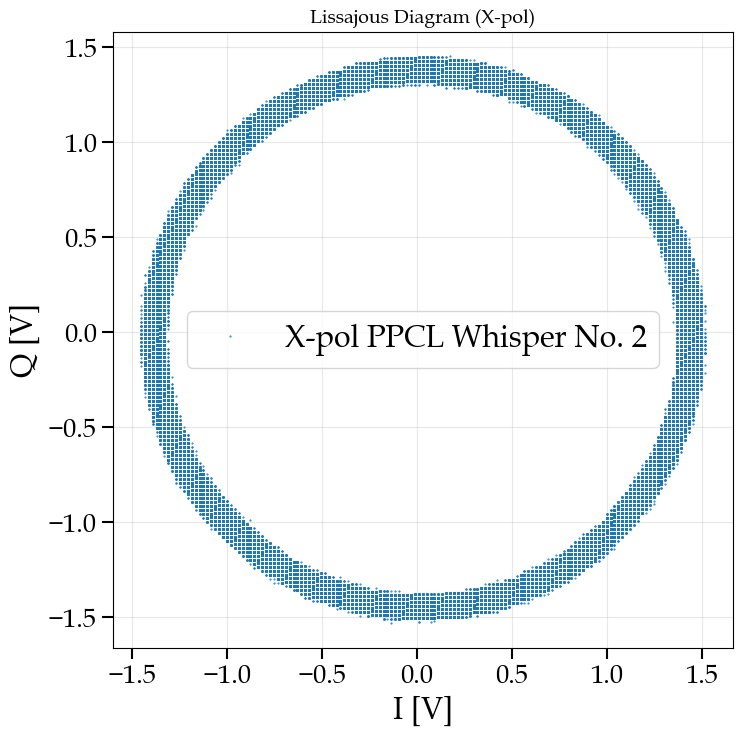

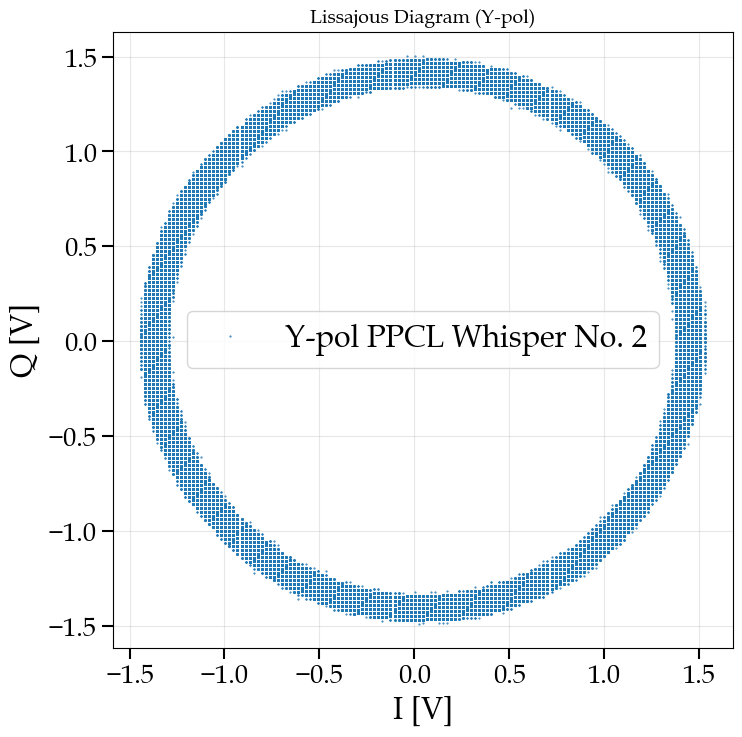

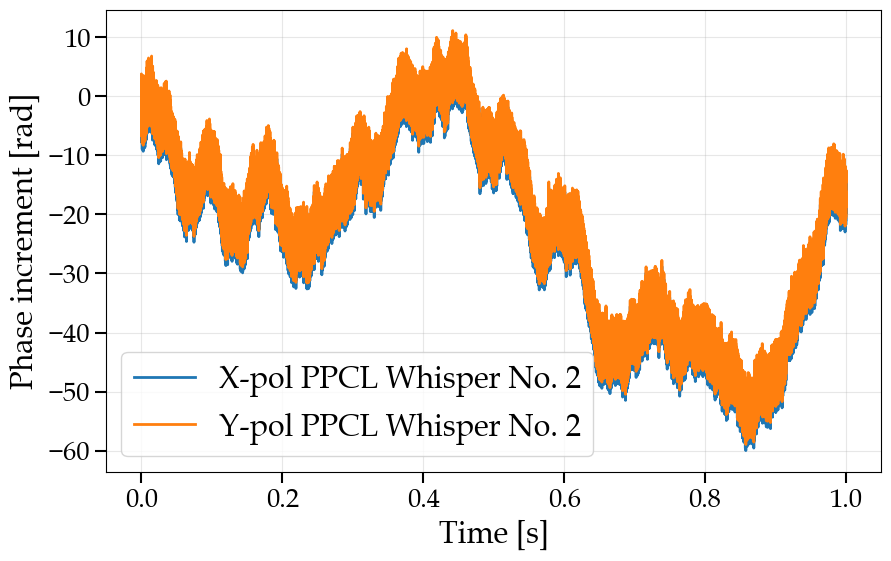

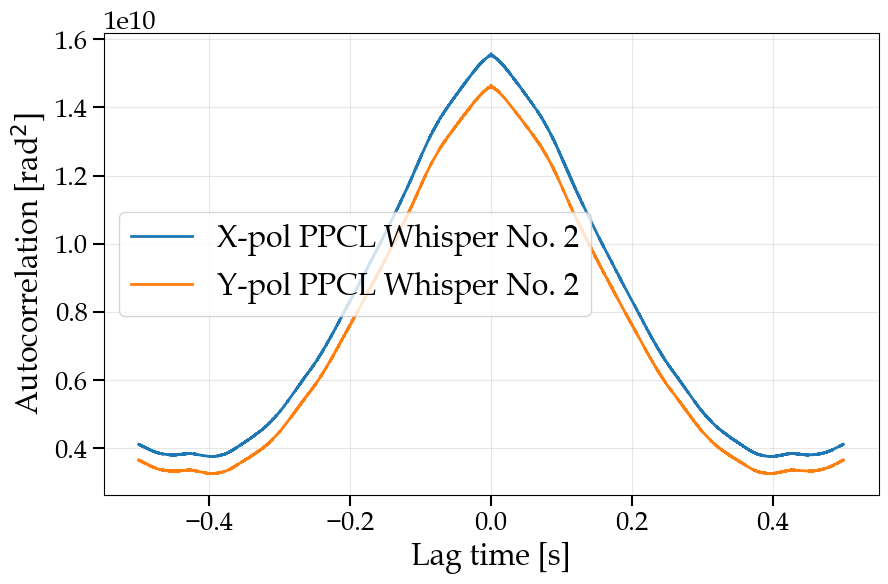

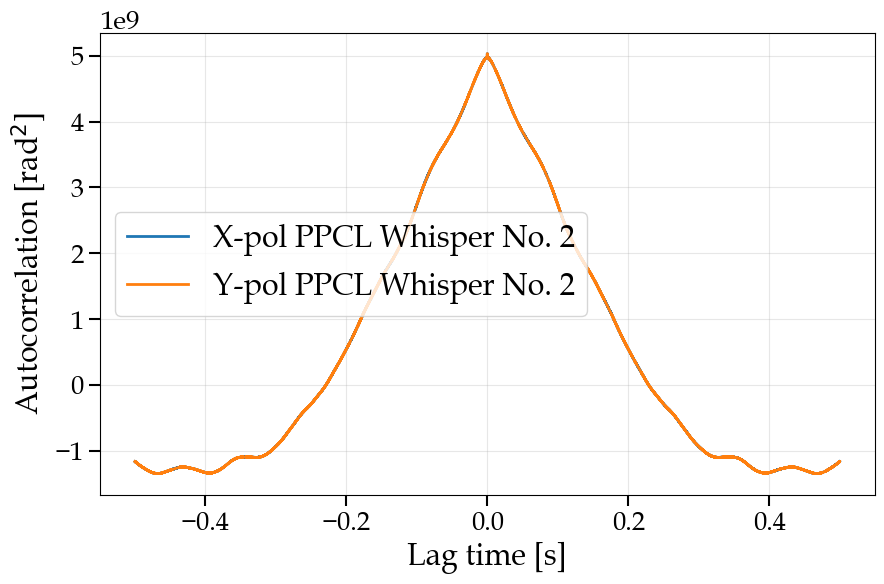

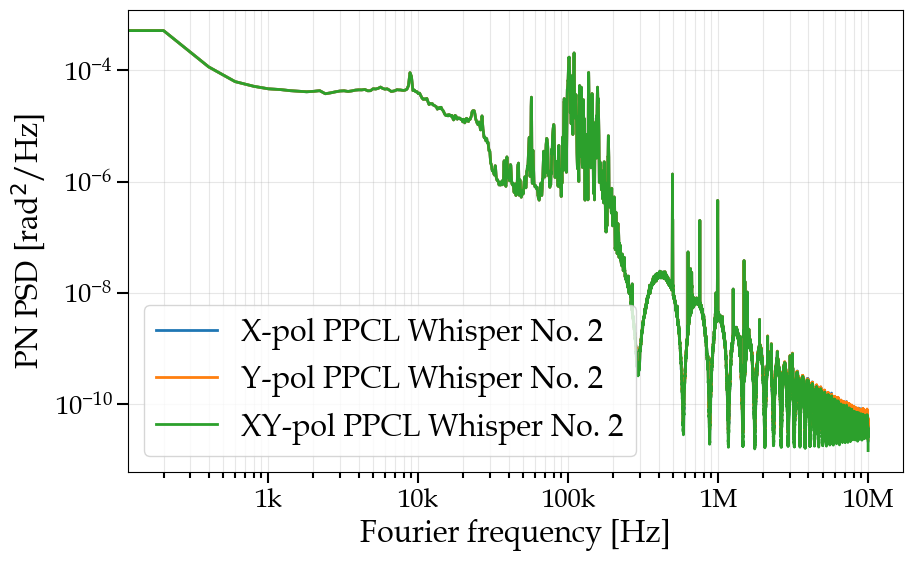

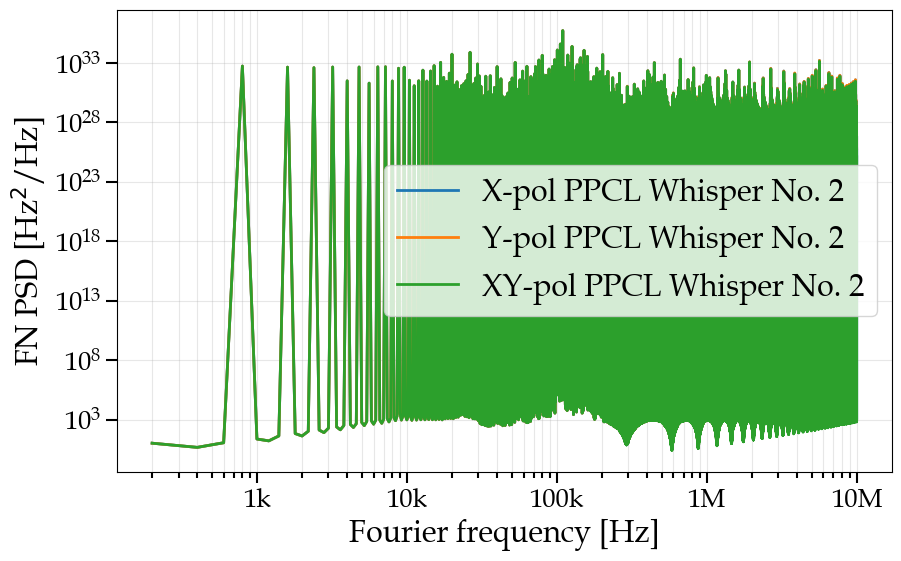

In [18]:
no = 2
savefolder = r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026_HHI_figures"
for mode in ["Whisper", "Dither"]:

    plot_analysis_overview(label_name=f"PPCL {mode} No. {no}", result=data_PPCL[mode]["No. "+str(no)], save_folder=savefolder)
    




In [32]:
f = data_PPCL["Whisper"]["No. 2"]["frequency_domain"]["frequency"]
pn_x = data_PPCL["Whisper"]["No. 2"]["frequency_domain"]["pn_x"]
pn_y = data_PPCL["Whisper"]["No. 2"]["frequency_domain"]["pn_y"]
pn_xy = data_PPCL["Whisper"]["No. 2"]["frequency_domain"]["pn_xy"]

fn_x = data_PPCL["Whisper"]["No. 2"]["frequency_domain"]["fn_x"]
fn_y = data_PPCL["Whisper"]["No. 2"]["frequency_domain"]["fn_y"]
fn_xy = data_PPCL["Whisper"]["No. 2"]["frequency_domain"]["fn_xy"]

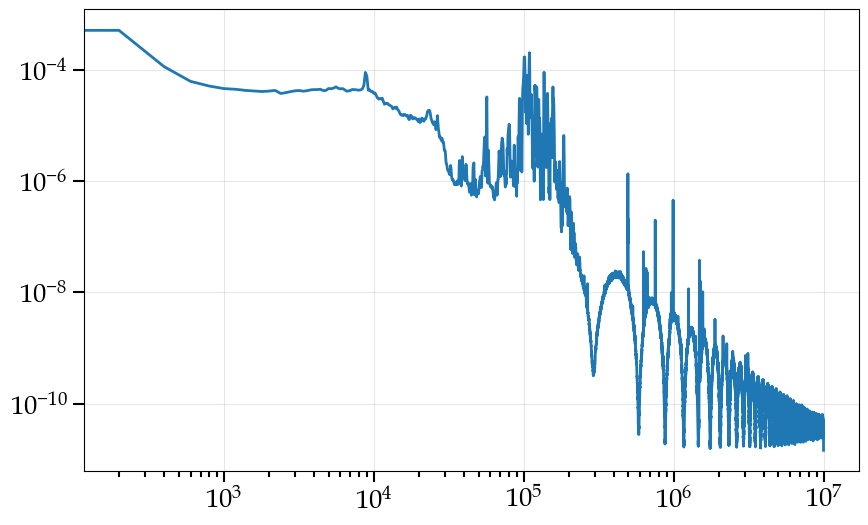

In [33]:
plt.plot(f, pn_xy, label="X-pol")
plt.yscale("log")
plt.xscale("log")


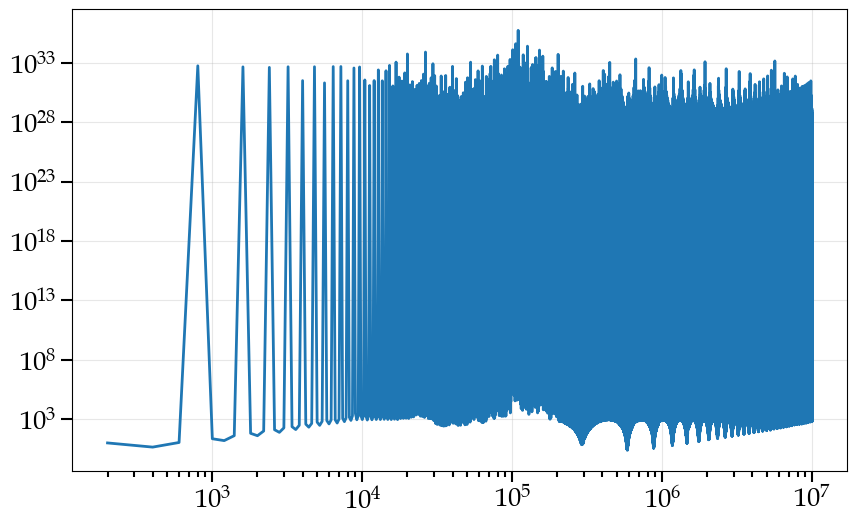

In [31]:
plt.plot(f, fn_xy, label="X-pol")
plt.yscale("log")
plt.xscale("log")


In [36]:
folder_dither = r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Dither"
folder_whisper = r"C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Whisper"


data_PPCL = {"Whisper": {}, "Dither": {}}

for mode in ["Whisper","Dither"]:
    folder = folder_whisper if mode == "Whisper" else folder_dither

    for i in range(2, 3):
        name = f"PPCL550_{mode}_14.66dBm_7.51+12.14dBm_no{i}.Wfm"
        
        data = pnpsd(name, folder, 200)

        data_PPCL[mode]["No. "+str(i)] = data if mode == "Whisper" else data_PPCL.update({name: data})

C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Whisper/PPCL550_Whisper_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
now proccessing file at path:  C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Whisper/PPCL550_Whisper_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
Size:  20000000
Frequency resolution:  20000000.0
C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Dither/PPCL550_Dither_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
now proccessing file at path:  C:\Users\au617810\OneDrive - Aarhus universitet\O-drive - Jeppe\Coherent receiver\29_07_2026 HHI Data\HHI Coherent receiver\PPCL Dither/PPCL550_Dither_14.66dBm_7.51+12.14dBm_no2.Wfm.csv
Size:  20000000
Frequency resolution:  20000000.0


In [37]:
data_PPCL["Whisper"]["No. 2"]

(array([0.0000e+00, 2.0000e+02, 4.0000e+02, ..., 9.9996e+06, 9.9998e+06,
        1.0000e+07], shape=(50001,)),
 array([3.80283588e-05, 5.16980897e-04, 1.14970076e-04, ...,
        4.00649723e-11, 4.23563620e-11, 2.17414876e-11], shape=(50001,)),
 array([0.0000e+00, 2.0000e+02, 4.0000e+02, ..., 9.9996e+06, 9.9998e+06,
        1.0000e+07], shape=(50001,)),
 array([3.80291895e-05, 5.16995954e-04, 1.14978850e-04, ...,
        4.21500068e-11, 4.45871706e-11, 2.29355994e-11], shape=(50001,)),
 array([0.0000e+00, 2.0000e+02, 4.0000e+02, ..., 9.9996e+06, 9.9998e+06,
        1.0000e+07], shape=(50001,)),
 array([3.80287684e-05, 5.16988391e-04, 1.14974437e-04, ...,
        2.82833782e-11, 2.90090623e-11, 1.45180957e-11], shape=(50001,)))